# Forward Model: Wrought Alloys

Predicts alloy properties from composition. Uses hyperparameters from `hyperparams_config.json` (run 01_hyperparameter_tuning_forward.ipynb first).

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

try:
    from utils import load_hyperparams, load_hyperparams_for_target, get_default_hyperparams
except ImportError:
    import sys
    sys.path.insert(0, os.getcwd())
    from utils import load_hyperparams, load_hyperparams_for_target, get_default_hyperparams

FILE_PATH = 'wrought_alloys_final.csv'

In [2]:
# MODULE 1: DATA ENGINEERING
class AlloyDataProcessor:
    def __init__(self, file_path):
        self.file_path = file_path
        self.raw_data = None
        self.clean_data = None
        self.input_cols = ['Al', 'Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Ni', 'Zn', 'Ga', 'V', 'Ti']
        self.target_cols = []

    def load_and_clean(self):
        print(f"[{'='*20} LOADING DATA {'='*20}")
        try:
            if self.file_path.endswith('.xlsx') or self.file_path.endswith('.xls'):
                self.raw_data = pd.read_excel(self.file_path)
            else:
                with open(self.file_path, 'rb') as f:
                    if f.read(2) == b'PK':
                        self.raw_data = pd.read_excel(self.file_path)
                    else:
                        try:
                            self.raw_data = pd.read_csv(self.file_path, encoding='utf-8')
                        except UnicodeDecodeError:
                            self.raw_data = pd.read_csv(self.file_path, encoding='latin-1')
            print(f"File loaded successfully. Shape: {self.raw_data.shape}")
        except Exception as e:
            print(f"Error loading file: {e}")
            return None
        exclude = self.input_cols + ['Series', 'Parent Alloy', 'Alloy Name', 'AlloyNumber', 'Temper']
        self.target_cols = [c for c in self.raw_data.columns if c not in exclude]
        df = self.raw_data.copy()
        print("Cleaning non-numeric values...")
        for col in self.input_cols + self.target_cols:
            if col in df.columns:
                df[col] = df[col].apply(self._parse_value)
        df[self.input_cols] = df[self.input_cols].fillna(0.0)
        self.clean_data = df
        print(f"Data Cleaning Complete. Processed {len(self.input_cols)} Inputs and {len(self.target_cols)} Targets.")
        return self.clean_data

    def _parse_value(self, val):
        if pd.isna(val) or val == '': return np.nan
        val = str(val).strip()
        if '-' in val:
            try:
                parts = [re.sub(r'[^\d\.]', '', p) for p in val.split('-')]
                return (float(parts[0]) + float(parts[1])) / 2
            except: pass
        m = re.search(r"[-+]?\d*\.\d+|\d+", val)
        return float(m.group()) if m else np.nan

    def generate_eda_report(self):
        print(f"\n[{'='*20} EDA REPORT {'='*20}")
        df = self.clean_data
        key_targets = self.target_cols[:5] if len(self.target_cols) > 5 else self.target_cols
        corr_data = df[self.input_cols + key_targets].corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_data, cmap='coolwarm', annot=False, linewidths=0.5)
        plt.title("Correlation Matrix: Composition vs Properties")
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(8, 4))
        sns.histplot(df['Al'], kde=True, color='blue')
        plt.title("Distribution of Aluminum Content")
        plt.show()

In [3]:
# MODULE 2: MODEL TRAINING (with loaded hyperparams)
def build_model(name, params):
    p = params.copy() if params else get_default_hyperparams(name)
    if name == 'XGBoost':
        return xgb.XGBRegressor(objective='reg:squarederror', **{k: v for k, v in p.items()})
    if name == 'RandomForest':
        return RandomForestRegressor(**{k: v for k, v in p.items()})
    if name == 'GradientBoosting':
        return GradientBoostingRegressor(**{k: v for k, v in p.items()})
    return None

class ForwardModelTrainer:
    def __init__(self, data, input_cols, hyperparams=None):
        self.data = data
        self.inputs = input_cols
        self.best_models = {}
        self.metrics = {}
        self.hp = hyperparams or load_hyperparams('wrought')

    def train_all_targets(self, target_list):
        print(f"\n[{'='*20} MODEL TRAINING {'='*20}")
        for target in target_list:
            valid_rows = self.data.dropna(subset=[target])
            if len(valid_rows) < 50: continue
            print(f"\n>> TARGET: {target} (n={len(valid_rows)})")
            X = valid_rows[self.inputs]
            y = valid_rows[target]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            spec = load_hyperparams_for_target('wrought', target)
            if spec and spec.get('model') and spec.get('params'):
                name = spec['model']
                params = spec['params']
                model = build_model(name, params)
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                best_r2 = r2_score(y_test, preds)
                winner_name = name
                winner_model = model
                mae_c = mean_absolute_error(y_test, preds)
                rmse_c = np.sqrt(mean_squared_error(y_test, preds))
                print(f"   {name} (from config): R²={best_r2:.4f}, MAE={mae_c:.2f}, RMSE={rmse_c:.2f}")
            else:
                best_r2 = -float('inf')
                winner_name = None
                winner_model = None
                print("   (No wrought.by_target for this target; comparing XGB/RF/GB)")
                for name in ['RandomForest', 'XGBoost', 'GradientBoosting']:
                    params = self.hp.get(name) if self.hp else get_default_hyperparams(name)
                    model = build_model(name, params)
                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    r2 = r2_score(y_test, preds)
                    mae_m = mean_absolute_error(y_test, preds)
                    print(f"   {name}: R²={r2:.4f}, MAE={mae_m:.2f}")
                    if r2 > best_r2:
                        best_r2 = r2
                        winner_name = name
                        winner_model = model
            self.best_models[target] = winner_model
            mae = mean_absolute_error(y_test, winner_model.predict(X_test))
            rmse = np.sqrt(mean_squared_error(y_test, winner_model.predict(X_test)))
            self.metrics[target] = {'Model': winner_name, 'R2': best_r2, 'MAE': mae, 'RMSE': rmse}
            print(f"   WINNER: {winner_name} | R²={best_r2:.4f} | MAE={mae:.2f} | RMSE={rmse:.2f}")

    def plot_feature_importance(self, target_name):
        if target_name not in self.best_models: return
        model = self.best_models[target_name]
        if hasattr(model, 'feature_importances_'):
            imps = model.feature_importances_
            indices = np.argsort(imps)[::-1]
            plt.figure(figsize=(10, 5))
            plt.title(f"Feature Importance for {target_name}")
            plt.bar(range(len(self.inputs)), imps[indices], align='center')
            plt.xticks(range(len(self.inputs)), [self.inputs[i] for i in indices])
            plt.tight_layout()
            plt.show()

def predict_full_profile(composition, trainer):
    input_df = pd.DataFrame([composition])
    for col in trainer.inputs:
        if col not in input_df.columns: input_df[col] = 0.0
    input_df = input_df[trainer.inputs]
    print(f"\n[{'='*20} PREDICTED ALLOY DATASHEET {'='*20}]")
    print(f"Composition: {composition}")
    print("-" * 65)
    for target, model in trainer.best_models.items():
        val = model.predict(input_df)[0]
        unit = "MPa" if "MPa" in target else "GPa" if "GPa" in target else "%" if "%" in target else ""
        print(f"{target:<40} | {val:>10.2f} | {unit}")

[==================== LOADING DATA ====================


File loaded successfully. Shape: (868, 31)
Cleaning non-numeric values...
Data Cleaning Complete. Processed 12 Inputs and 14 Targets.

[==================== EDA REPORT ====================


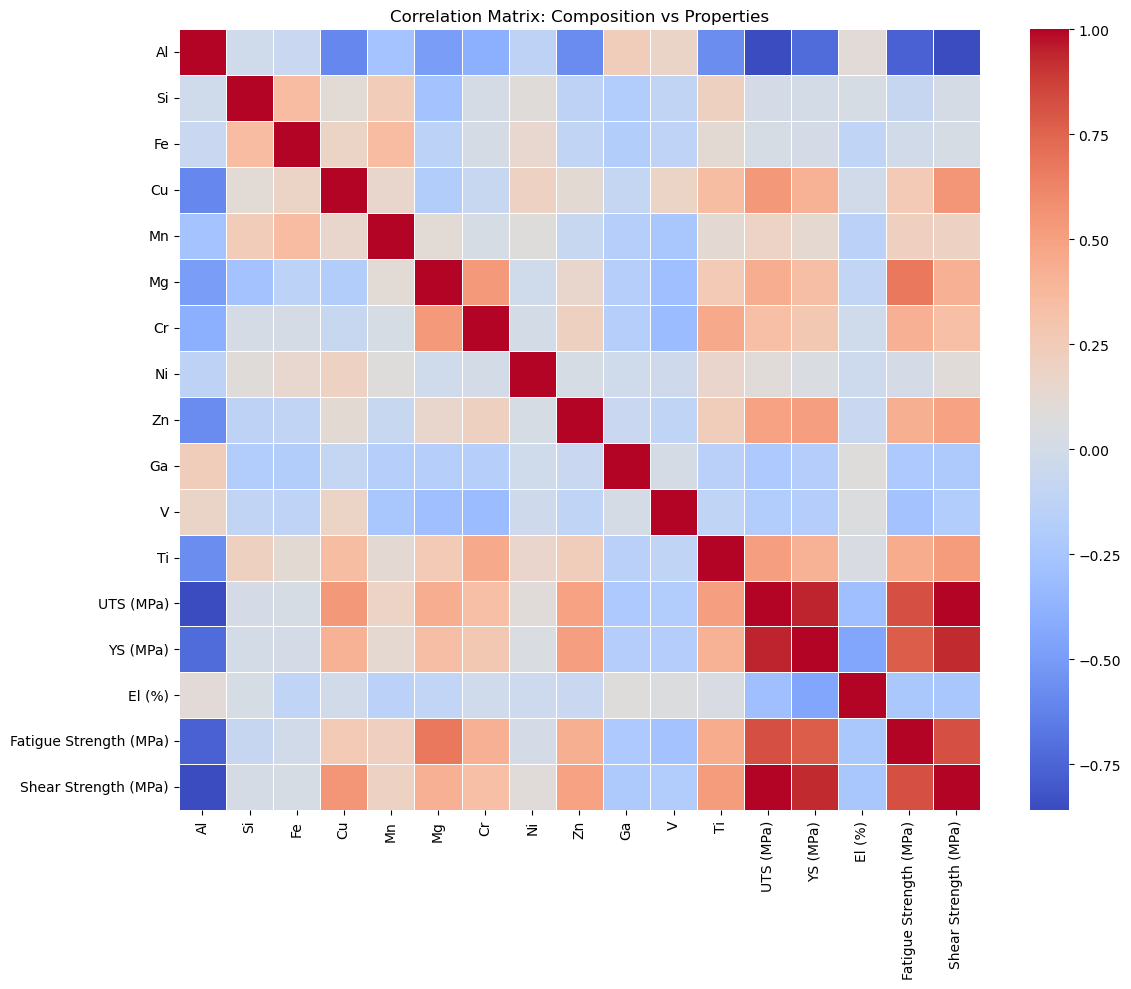

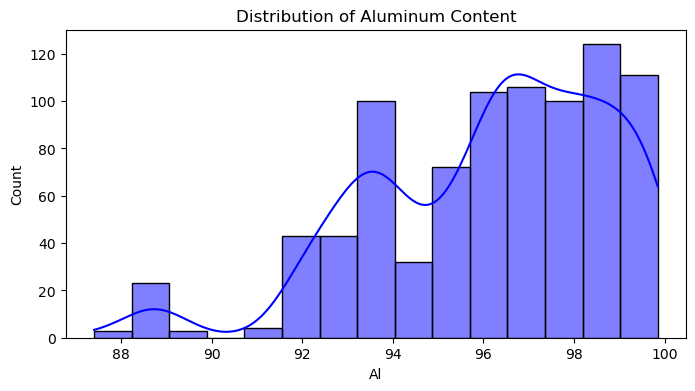


[==================== MODEL TRAINING ====================

>> TARGET: UTS (MPa) (n=865)


   RandomForest (from config): R²=0.8730, MAE=35.43, RMSE=45.01
   WINNER: RandomForest | R²=0.8730 | MAE=35.43 | RMSE=45.01

>> TARGET: YS (MPa) (n=854)


   GradientBoosting (from config): R²=0.6482, MAE=53.78, RMSE=71.35
   WINNER: GradientBoosting | R²=0.6482 | MAE=53.78 | RMSE=71.35

>> TARGET: El (%) (n=858)


   XGBoost (from config): R²=0.0334, MAE=4.97, RMSE=6.22
   WINNER: XGBoost | R²=0.0334 | MAE=4.97 | RMSE=6.22

>> TARGET: Fatigue Strength (MPa) (n=850)


   GradientBoosting (from config): R²=0.7962, MAE=13.41, RMSE=17.91
   WINNER: GradientBoosting | R²=0.7962 | MAE=13.41 | RMSE=17.91

>> TARGET: Shear Strength (MPa) (n=857)


...

   WINNER: XGBoost | R²=1.0000 | MAE=0.00 | RMSE=0.01

>> TARGET: TC (W/m-K) (n=868)
   XGBoost (from config): R²=0.9845, MAE=0.86, RMSE=4.70
   WINNER: XGBoost | R²=0.9845 | MAE=0.86 | RMSE=4.70

>> TARGET: TE Coeff (n=868)


   GradientBoosting (from config): R²=0.9999, MAE=0.00, RMSE=0.00
   WINNER: GradientBoosting | R²=0.9999 | MAE=0.00 | RMSE=0.00

>> TARGET: Thermal Diffusivity  (n=868)


   XGBoost (from config): R²=0.9894, MAE=0.30, RMSE=1.67
   WINNER: XGBoost | R²=0.9894 | MAE=0.30 | RMSE=1.67

>> TARGET: EC Volume (% IACS) (n=868)


   XGBoost (from config): R²=0.9862, MAE=0.25, RMSE=1.27
   WINNER: XGBoost | R²=0.9862 | MAE=0.25 | RMSE=1.27

>> TARGET: EC Weight (% IACS) (n=868)


   XGBoost (from config): R²=0.9833, MAE=1.11, RMSE=4.79
   WINNER: XGBoost | R²=0.9833 | MAE=1.11 | RMSE=4.79

Feature Importance for UTS:


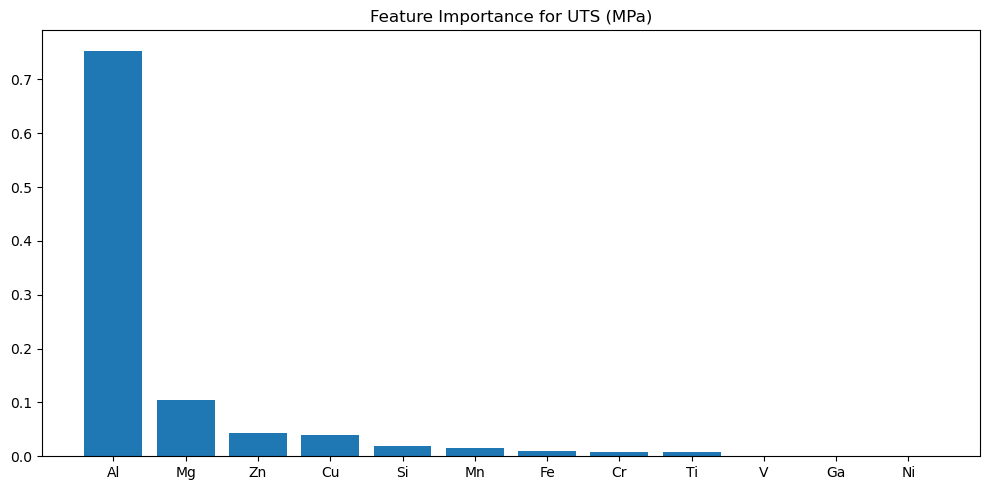


[==================== PREDICTED ALLOY DATASHEET ====================]
Composition: {'Al': 90.0, 'Zn': 5.5, 'Mg': 2.5, 'Cu': 1.5, 'Cr': 0.2}
-----------------------------------------------------------------
UTS (MPa)                                |     536.54 | MPa
YS (MPa)                                 |     437.02 | MPa
El (%)                                   |       8.77 | %
Fatigue Strength (MPa)                   |     173.18 | MPa
Shear Strength (MPa)                     |     314.08 | MPa
Y (GPa)                                  |      70.03 | GPa
G (GPa)                                  |      25.19 | GPa
Density (g/cc)                           |       3.00 | 
Cp (J/kg-K)                              |     873.51 | 
TC (W/m-K)                               |     141.27 | 
TE Coeff                                 |      23.48 | 
Thermal Diffusivity                      |      54.07 | 
EC Volume (% IACS)                       |      34.67 | %
EC Weight (% IACS)              

In [4]:
# MAIN EXECUTION
processor = AlloyDataProcessor(FILE_PATH)
df_clean = processor.load_and_clean()

if df_clean is not None:
    processor.generate_eda_report()
    trainer = ForwardModelTrainer(df_clean, processor.input_cols)
    trainer.train_all_targets(processor.target_cols)
    if 'UTS (MPa)' in trainer.best_models:
        print("\nFeature Importance for UTS:")
        trainer.plot_feature_importance('UTS (MPa)')
    test_alloy = {'Al': 90.0, 'Zn': 5.5, 'Mg': 2.5, 'Cu': 1.5, 'Cr': 0.2}
    predict_full_profile(test_alloy, trainer)